In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pickle
import sys
sys.path.append('/scratch/vdeltatt/imbalance-gain-causality')
from utilities import construct_time_delay_embedding
from tqdm import tqdm

plt.style.use(['science','notebook'])

### Try with 'copent' library

In [ ]:
from copent import transent

In [27]:
seed = 0#int(sys.argv[1])
epsilons = np.linspace(0.,0.25,30)
sample_traj = pickle.load(open(f"../fig3_errors/trajs/rossler_diff/seed0_ieps0.p","rb"))
N = 10000
tau = 5
k = 3
n_jobs = 8
alphas = np.linspace(0.,0.25,50)

# parameters for time-delay embeddings
E = 3
tau_e = 1
#traj_length = sample_traj.shape[0] - tau_e*E
#sample_times = np.linspace(100000,traj_length-tau-1,N,dtype=int)

transfer_entropies = []

for ieps, eps in tqdm(enumerate(epsilons)):
    trajectory = pickle.load(open(f"../fig3_errors/trajs/rossler_diff/seed{seed}_ieps{ieps}.p","rb"))
    assert trajectory.shape == sample_traj.shape

    #X_time_delay, Y_time_delay = construct_time_delay_embedding(X=trajectory[:,1], Y=trajectory[:,4], E=E, tau_e=tau_e)
   
    transfer_entropies.append( transent(trajectory[:N,1], trajectory[:N,4], lag=tau, k=k, dtype="euclidean") )

0it [00:00, ?it/s]

30it [09:27, 18.93s/it]


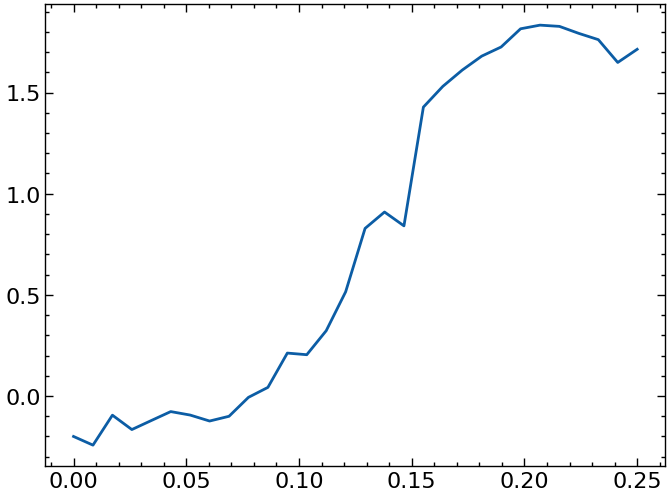

In [25]:
plt.plot(epsilons, transfer_entropies)

### Try with PyInform library

In [2]:
from pyinform.transferentropy import transfer_entropy

In [8]:
seed = 0#int(sys.argv[1])
epsilons = np.linspace(0.,0.25,30)
sample_traj = pickle.load(open(f"../fig3_errors/trajs/rossler_diff/seed0_ieps0.p","rb"))
N = 1000
tau = 5
k = 3
n_jobs = 8
alphas = np.linspace(0.,0.25,50)

# parameters for time-delay embeddings
E = 3
tau_e = 1
#traj_length = sample_traj.shape[0] - tau_e*E
#sample_times = np.linspace(100000,traj_length-tau-1,N,dtype=int)

transfer_entropies = []

for ieps, eps in tqdm(enumerate(epsilons)):
    trajectory = pickle.load(open(f"../fig3_errors/trajs/rossler_diff/seed{seed}_ieps{ieps}.p","rb"))
    assert trajectory.shape == sample_traj.shape

    #X_time_delay, Y_time_delay = construct_time_delay_embedding(X=trajectory[:,1], Y=trajectory[:,4], E=E, tau_e=tau_e)
   
    transfer_entropies.append( 
        transfer_entropy(np.array(trajectory[:N,1], dtype=bool), np.array(trajectory[:N,4], dtype=bool), k=k) 
    )

0it [00:00, ?it/s]

30it [00:00, 103.66it/s]


### Try with IDTxl library

In [10]:
from idtxl.bivariate_te import BivariateTE
from idtxl.data import Data 

In [12]:
sample_traj = pickle.load(open(f"../fig3_errors/trajs/rossler_diff/seed0_ieps0.p","rb"))
prova = construct_time_delay_embedding(sample_traj[:,1], E=30, tau_e=1)

In [13]:
prova.shape

(204971, 30)

In [8]:
seed = 0#int(sys.argv[1])
epsilons = np.linspace(0.,0.25,30)
sample_traj = pickle.load(open(f"../fig3_errors/trajs/rossler_diff/seed0_ieps0.p","rb"))
N = 1000
tau = 5
k = 3
n_jobs = 8
alphas = np.linspace(0.,0.25,50)

# parameters for time-delay embeddings
E = 3
tau_e = 1
#traj_length = sample_traj.shape[0] - tau_e*E
#sample_times = np.linspace(100000,traj_length-tau-1,N,dtype=int)

transfer_entropies = []

for ieps, eps in tqdm(enumerate(epsilons)):
    trajectory = pickle.load(open(f"../fig3_errors/trajs/rossler_diff/seed{seed}_ieps{ieps}.p","rb"))
    assert trajectory.shape == sample_traj.shape

    #X_time_delay, Y_time_delay = construct_time_delay_embedding(X=trajectory[:,1], Y=trajectory[:,4], E=E, tau_e=tau_e)
   
    concatenated = np.column_stack((trajectory[:,1], trajectory[:,4]))
    data = Data(concatenated, dim_order='sp')
    transfer_entropies.append( 
        transfer_entropy(np.array(trajectory[:N,1], dtype=bool), np.array(trajectory[:N,4], dtype=bool), k=k) 
    )




Adding data with properties: 5 processes, 100 samples, 5 replications
overwriting existing data


In [12]:
data.get_realisations()

TypeError: get_realisations() missing 2 required positional arguments: 'current_value' and 'idx_list'

In [ ]:
data = Data()
data.generate_mute_data(100, 5)
settings = {
    'cmi_estimator':  'JidtKraskovCMI',
    'n_perm_max_stat': 200,
    'n_perm_min_stat': 200,
    'n_perm_omnibus': 500,
    'n_perm_max_seq': 500,
    'max_lag_sources': 5,
    'min_lag_sources': 2
    }
target = 0
sources = [1, 2, 3]
network_analysis = MultivariateTE()
results = network_analysis.analyse_single_target(settings,
                                                 data, target,
                                                 sources)

### Try with 'knncmi' library

In [3]:
import knncmi
import pandas as pd

In [6]:
a = np.zeros((100,6))
dataset = pd.DataFrame(a)
print(list(dataset))

[0, 1, 2, 3, 4, 5]


In [19]:
import pandas as pd

# Read dataset to pandas dataframe
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
names = ['slength', 'swidth', 'plength', 'pwidth', 'class']
dataset = pd.read_csv(url, names=names)

# estimate CMI between 'slength' and 'swidth' given 'class'
print(knncmi.cmi(['slength','plength','class'], ['swidth'], ['class'], 3, dataset))
# 0.24623572430840526

print(knncmi.cmi([0,2,4], [1], [4], 3, dataset))


0.21325406121092272
0.21325406121092272


In [9]:
dataset[5]

0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
     ... 
95    0.0
96    0.0
97    0.0
98    0.0
99    0.0
Name: 5, Length: 100, dtype: float64

In [16]:
seed = 0 #int(sys.argv[1])
epsilons = np.linspace(0.,0.25,30)
sample_traj = pickle.load(open(f"../fig3_errors/trajs/rossler_diff/seed0_ieps0.p","rb"))
N = 5000
tau = 5
k = 3
#n_jobs = 8
#alphas = np.linspace(0.,0.25,50)

# parameters for time-delay embeddings
E = 3
tau_e = 1
traj_length = sample_traj.shape[0] - tau_e*E
sample_times = np.linspace(100000,traj_length-tau-1,N,dtype=int)

transfer_entropies = np.ones((len(epsilons), 2))

for ieps, eps in tqdm(enumerate(epsilons)):
    trajectory = pickle.load(open(f"../fig3_errors/trajs/rossler_diff/seed{seed}_ieps{ieps}.p","rb"))
    assert trajectory.shape == sample_traj.shape

    # all coordinates
    X0 = trajectory[sample_times,1:4]
    Y0 = trajectory[sample_times,4:]
    Xtau = trajectory[sample_times+tau,1:4]
    Ytau = trajectory[sample_times+tau,4:]

    variable_names = ['x1_0', 'x2_0', 'x3_0', 'y1_0', 'y2_0', 'y3_0', 'x1_tau', 'x2_tau', 'x3_tau', 'y1_tau', 'y2_tau', 'y3_tau']
    dataset = pd.DataFrame(np.column_stack((X0,Y0,Xtau,Ytau)), columns=variable_names)

    transfer_entropies[ieps,0] = (
        knncmi.cmi(['x1_0','x2_0','x3_0'], ['y1_tau', 'y2_tau', 'y3_tau'], ['y1_0', 'y2_0', 'y3_0'], k, dataset)
    )
    transfer_entropies[ieps,1] = (
        knncmi.cmi(['y1_0','y2_0','y3_0'], ['x1_tau', 'x2_tau', 'x3_tau'], ['x1_0', 'x2_0', 'x3_0'], k, dataset)
    )

    # time-delay embeddings
    #X_time_delay, Y_time_delay = construct_time_delay_embedding(X=trajectory[:,1], Y=trajectory[:,4], E=E, tau_e=tau_e)

0it [00:00, ?it/s]

30it [06:52, 13.75s/it]


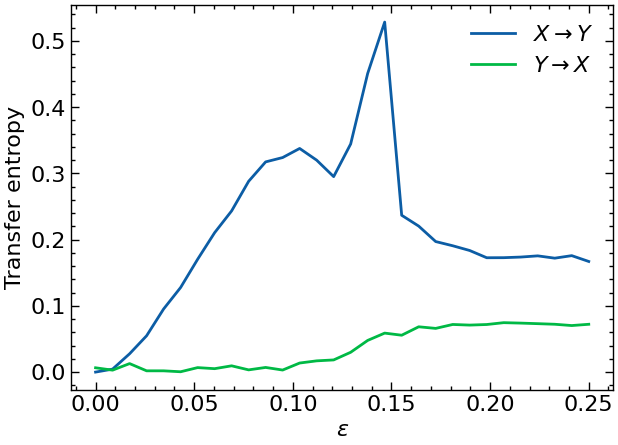

In [17]:
plt.figure(figsize=(7,5))
plt.plot(epsilons, transfer_entropies[:,0], label="$X\\rightarrow Y$")
plt.plot(epsilons, transfer_entropies[:,1], label="$Y\\rightarrow X$")
plt.xlabel("$\\varepsilon$")
plt.ylabel("Transfer entropy")
plt.legend()
plt.show()

In [47]:
import pandas as pd
sys.path.append('/scratch/vdeltatt/imbalance-gain-causality')
from utilities import construct_time_delay_embedding
import knncmi
import pandas as pd

D = 30
E = 30
tau_e = 1
trajectory = pickle.load(open(f"../fig3_errors/trajs/lorenz96/seed0_ieps0.p","rb"))
sample_times = np.arange(100)
tau = 5

X_time_delay = construct_time_delay_embedding(X=trajectory[:,1], E=E, tau_e=tau_e)
Y_time_delay = construct_time_delay_embedding(X=trajectory[:,D+1], E=E, tau_e=tau_e)
X0 = X_time_delay[sample_times]
Y0 = Y_time_delay[sample_times]
Xtau = X_time_delay[sample_times+tau]
Ytau = Y_time_delay[sample_times+tau]

del X_time_delay, Y_time_delay

dataset = pd.DataFrame(np.column_stack((X0,Y0,Xtau,Ytau))) #

In [48]:
dataset.shape

(100, 120)

In [59]:
E = 30
#knncmi.cmi(list(np.array([0,1,2])), list(np.array([9,10,11])), list(np.array([3,4,5])), 3, dataset) #np.arange(3*E,4*E)
knncmi.cmi(list(np.arange(E)), list(np.arange(3*E,4*E)), list(np.arange(E,2*E)), 3, dataset) #np.arange(3*E,4*E)

0.10128544682236294